# M20 · Fine-tuning & Distillation — ✍️ Toy Example, Step by Tiny Step

**Companion to lesson M20. Written for someone new to ML.**

This notebook explains two practical moves after pretraining:

- **Fine-tune** = adapt a pretrained model to your task by training some weights on task examples.
- **Distill** = shrink knowledge from a strong **teacher** model into a smaller **student** model.

We use tiny numbers only: no internet, no downloads, no big models. Every code cell prints the numbers it computes and draws a picture, so you can trace the whole chain: **pretrained → fine-tune → teacher → distill → student → serve**.

## Step 0 · Setup

Import NumPy for arrays and Matplotlib for pictures. Fix the random seed so results repeat. Define:

- `log(label, value)` = a tiny print helper.
- `softmax(z, T=1.0)` = turns raw scores called **logits** into probabilities that sum to 1.
- **temperature** `T` = a knob that makes softmax sharper (`T=1`) or smoother (`T>1`).

In [2]:
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(0)
plt.rcParams["figure.figsize"] = (6, 4)

def log(label, value):
    print(f"[{label}] {value}")

def softmax(z, T=1.0):
    z = np.array(z, dtype=float) / T
    z = z - np.max(z)
    e = np.exp(z)
    return e / e.sum()

probe = softmax([1.0, 2.0, 3.0])
log("setup", "NumPy + Matplotlib ready; seed fixed to 0")
log("softmax([1,2,3])", np.round(probe, 3).tolist())
log("probability sum", round(float(probe.sum()), 6))
assert abs(probe.sum() - 1.0) < 1e-12

[setup] NumPy + Matplotlib ready; seed fixed to 0
[softmax([1,2,3])] [0.09, 0.245, 0.665]
[probability sum] 1.0


## Step 0b Toy example · Softmax makes probabilities

**Logits** are raw model scores; they are not probabilities yet. **Softmax** exponentiates and normalizes them, so the bars add up to 1.

Good for: reading a model's class preferences.  
Watch out for: a larger logit gap can make one probability dominate.

[toy logits] [1.0, 2.0, 3.0]
[exp-normalized probabilities] [0.09, 0.245, 0.665]
[sum check] 1.0


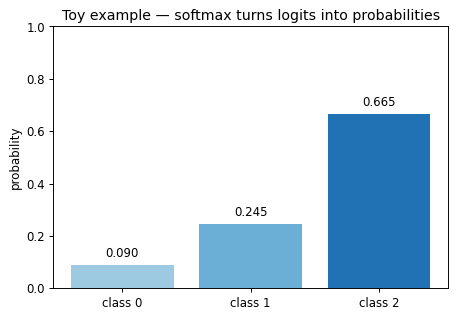

In [4]:
toy_logits = np.array([1.0, 2.0, 3.0])
toy_probs = softmax(toy_logits)
log("toy logits", toy_logits.tolist())
log("exp-normalized probabilities", np.round(toy_probs, 3).tolist())
log("sum check", round(float(toy_probs.sum()), 6))
assert abs(toy_probs.sum() - 1.0) < 1e-12

plt.bar(["class 0", "class 1", "class 2"], toy_probs, color=["#9ecae1", "#6baed6", "#2171b5"])
plt.ylim(0, 1)
plt.ylabel("probability")
plt.title("Toy example — softmax turns logits into probabilities")
for i, p in enumerate(toy_probs):
    plt.text(i, p + 0.03, f"{p:.3f}", ha="center")
plt.show()

---
# Part A · Fine-tuning adapts a pretrained model

## Step 1 Toy example · What fine-tuning means

A **pretrained encoder** is a model already trained on broad data. It turns input into a feature vector. A **head** is a small task-specific layer placed on top, like a classifier. To **freeze** weights means "do not update them."

In **head-only fine-tuning**, the encoder is frozen and only the head changes.

[frozen encoder feature feat] [0.9, -0.2, 0.5, 0.1]
[task] classify the example as POS or NEG
[freeze means] the encoder feature stays fixed; the head learns


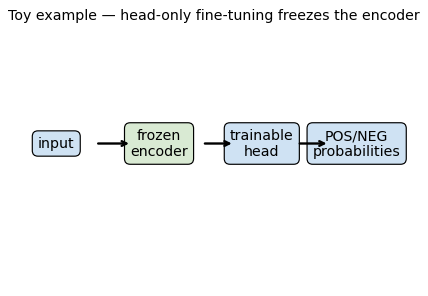

In [6]:
feat = np.array([0.9, -0.2, 0.5, 0.1])
log("frozen encoder feature feat", feat.tolist())
log("task", "classify the example as POS or NEG")
log("freeze means", "the encoder feature stays fixed; the head learns")

fig, ax = plt.subplots()
ax.axis("off")
boxes = [("input", 0.10), ("frozen\nencoder", 0.36), ("trainable\nhead", 0.62), ("POS/NEG\nprobabilities", 0.86)]
for text, x in boxes:
    color = "#d9ead3" if "frozen" in text else "#cfe2f3"
    ax.text(x, 0.55, text, ha="center", va="center", fontsize=12,
            bbox=dict(boxstyle="round,pad=0.4", facecolor=color, edgecolor="black"))
for x0, x1 in [(0.20, 0.29), (0.47, 0.55), (0.71, 0.79)]:
    ax.annotate("", xy=(x1, 0.55), xytext=(x0, 0.55), arrowprops=dict(arrowstyle="->", lw=2))
ax.set_title("Toy example — head-only fine-tuning freezes the encoder")
plt.show()

## Step 2 Toy example · Head-only logits before the update

The frozen feature is `feat = [0.9, -0.2, 0.5, 0.1]`. The 2-class head has weights `W` and bias `b`.

The head computes `logits = W @ feat + b`, then softmax gives class probabilities.

[W] [[0.1, -0.1, 0.2, 0.05], [-0.05, 0.15, -0.1, 0.2]]
[b] [0.0, 0.0]
[logits = W @ feat + b] [0.215, -0.105]
[softmax probabilities [POS, NEG]] [0.579, 0.421]


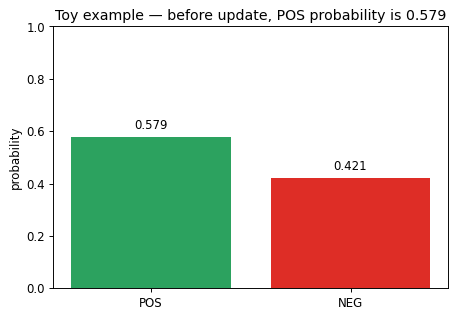

In [8]:
W_head = np.array([[0.10, -0.10,  0.20, 0.05],
                   [-0.05, 0.15, -0.10, 0.20]])
b_head = np.array([0.0, 0.0])
class_names = ["POS", "NEG"]

logits_before = W_head @ feat + b_head
p_before = softmax(logits_before)
log("W", W_head.tolist())
log("b", b_head.tolist())
log("logits = W @ feat + b", np.round(logits_before, 3).tolist())
log("softmax probabilities [POS, NEG]", np.round(p_before, 3).tolist())
assert np.allclose(np.round(logits_before, 3), [0.215, -0.105])
assert np.allclose(np.round(p_before, 3), [0.579, 0.421])

plt.bar(class_names, p_before, color=["#2ca25f", "#de2d26"])
plt.ylim(0, 1)
plt.ylabel("probability")
plt.title("Toy example — before update, POS probability is 0.579")
for i, p in enumerate(p_before):
    plt.text(i, p + 0.03, f"{p:.3f}", ha="center")
plt.show()

## Step 3 Toy example · The same gradient signal

The true label is POS, written as a **hard label** one-hot vector `y = [1, 0]`.

For softmax + cross-entropy, the gradient on logits is:

`grad_logits = predicted probabilities - true label`

That is the error signal. Full fine-tuning, head-only fine-tuning, and LoRA all start from this same signal; they differ in **which parameters are allowed to change**.

[true label y [POS, NEG]] [1.0, 0.0]
[predicted p [POS, NEG]] [0.579, 0.421]
[grad_logits = p - y] [-0.421, 0.421]
[gW = outer(grad_logits, feat)] [[-0.3786, 0.0841, -0.2103, -0.0421], [0.3786, -0.0841, 0.2103, 0.0421]]


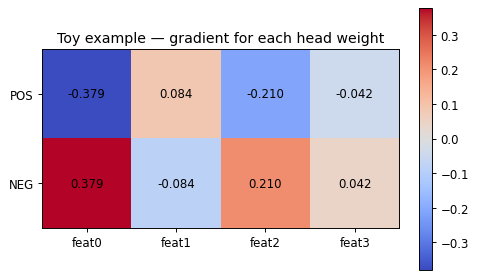

In [10]:
y_true = np.array([1.0, 0.0])
grad_logits = p_before - y_true
gW = np.outer(grad_logits, feat)
log("true label y [POS, NEG]", y_true.tolist())
log("predicted p [POS, NEG]", np.round(p_before, 3).tolist())
log("grad_logits = p - y", np.round(grad_logits, 3).tolist())
log("gW = outer(grad_logits, feat)", np.round(gW, 4).tolist())
assert np.allclose(np.round(grad_logits, 3), [-0.421, 0.421])

fig, ax = plt.subplots()
im = ax.imshow(gW, cmap="coolwarm")
ax.set_xticks(range(len(feat))); ax.set_xticklabels([f"feat{i}" for i in range(len(feat))])
ax.set_yticks([0, 1]); ax.set_yticklabels(class_names)
ax.set_title("Toy example — gradient for each head weight")
for i in range(gW.shape[0]):
    for j in range(gW.shape[1]):
        ax.text(j, i, f"{gW[i,j]:.3f}", ha="center", va="center")
plt.colorbar(im, ax=ax, fraction=0.046)
plt.show()

## Step 4 Toy example · One head-only gradient step

We update only `W` with learning rate `lr = 0.5` and keep the frozen encoder fixed. For hand-traceability, the bias stays at zero in this toy cell.

[learning rate] 0.5
[W before] [[0.1, -0.1, 0.2, 0.05], [-0.05, 0.15, -0.1, 0.2]]
[lr * gW] [[-0.1893, 0.0421, -0.1052, -0.021], [0.1893, -0.0421, 0.1052, 0.021]]
[W after = W - lr*gW] [[0.2893, -0.1421, 0.3052, 0.071], [-0.2393, 0.1921, -0.2052, 0.179]]
[new logits] [0.448, -0.338]
[POS probability before -> after] 0.579 -> 0.687


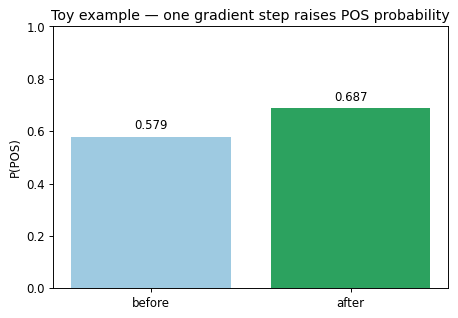

In [12]:
lr = 0.5
W_after = W_head - lr * gW
logits_after = W_after @ feat + b_head
p_after = softmax(logits_after)
log("learning rate", lr)
log("W before", np.round(W_head, 4).tolist())
log("lr * gW", np.round(lr * gW, 4).tolist())
log("W after = W - lr*gW", np.round(W_after, 4).tolist())
log("new logits", np.round(logits_after, 3).tolist())
log("POS probability before -> after", f"{p_before[0]:.3f} -> {p_after[0]:.3f}")
assert p_after[0] > p_before[0]
assert np.allclose(np.round(p_after, 3), [0.687, 0.313])

plt.bar(["before", "after"], [p_before[0], p_after[0]], color=["#9ecae1", "#2ca25f"])
plt.ylim(0, 1)
plt.ylabel("P(POS)")
plt.title("Toy example — one gradient step raises POS probability")
for i, p in enumerate([p_before[0], p_after[0]]):
    plt.text(i, p + 0.03, f"{p:.3f}", ha="center")
plt.show()

## Step 5 Toy example · Full FT vs head-only vs LoRA use the same gradient

- **Full fine-tuning (full-FT):** update many or all model weights. Good for maximum adaptation; watch out for cost and overfitting.
- **Head-only fine-tuning:** freeze the encoder, update only the task head. Good for cheap baselines; watch out when the frozen features are not enough.
- **LoRA:** freeze the big weight and train small low-rank adapter matrices. Good for cheap adaptation; watch out because very tiny rank can underfit.

[full-FT] same grad_logits [-0.421, 0.421] flows in, update ['encoder', 'head']
[head-only] same grad_logits [-0.421, 0.421] flows in, update ['head']
[LoRA] same grad_logits [-0.421, 0.421] flows in, update ['adapter A/B']


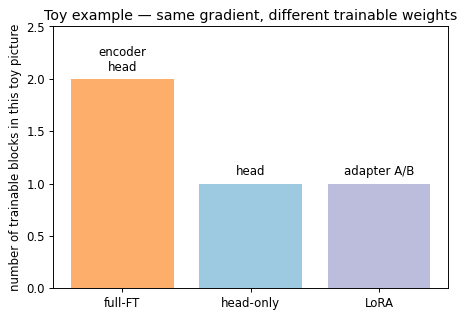

In [14]:
update_choices = {
    "full-FT": ["encoder", "head"],
    "head-only": ["head"],
    "LoRA": ["adapter A/B"],
}
for name, parts in update_choices.items():
    log(name, f"same grad_logits {np.round(grad_logits, 3).tolist()} flows in, update {parts}")

fig, ax = plt.subplots()
labels = list(update_choices.keys())
trainable_parts = [2, 1, 1]
colors = ["#fdae6b", "#9ecae1", "#bcbddc"]
ax.bar(labels, trainable_parts, color=colors)
ax.set_ylim(0, 2.5)
ax.set_ylabel("number of trainable blocks in this toy picture")
ax.set_title("Toy example — same gradient, different trainable weights")
for i, parts in enumerate(update_choices.values()):
    ax.text(i, trainable_parts[i] + 0.08, "\n".join(parts), ha="center")
plt.show()

---
# Part B · LoRA makes fine-tuning cheaper

## Step 6a Toy example · Why PEFT/LoRA exists

**PEFT** means **parameter-efficient fine-tuning**: adapt a model while training only a small number of new parameters.

Why this matters:

- Full fine-tuning must store a **gradient + optimizer state** for **every** weight.
- Full fine-tuning must save a full adapted model copy per task.
- LoRA's key insight: many useful task **adaptations** have low intrinsic **rank**, so the update can be forced into a tiny subspace.

Definitions:

- **Freeze** = keep a weight fixed; do not update it during training.
- **Rank** = how many independent directions a matrix update can express.
- **Outer product** = one column times one row; for example `[1, 2]^T @ [3, 4] = [[3, 4], [6, 8]]`.

## Step 6b Toy example · Frozen pretrained layer

Start with one tiny pretrained layer. The layer weight `W` stays **FROZEN**. A full fine-tune would train a free `3 × 3` update matrix `ΔW`, which is `9` trainable numbers in this toy layer.

In [17]:
W_lora = np.array([[2.0, 0.0, 1.0],
                   [0.0, 3.0, 0.0],
                   [1.0, 0.0, 2.0]])
x_lora = np.array([1.0, 2.0, 1.0])
y_base = W_lora @ x_lora
W_lora_before_training = W_lora.copy()

log("W frozen", W_lora.astype(int).tolist())
log("x", x_lora.astype(int).tolist())
log("y = W @ x", y_base.astype(int).tolist())
log("full fine-tune delta params", "3*3 = 9 free trainable numbers")
log("LoRA promise", "W stays frozen; only small adapter matrices train")
assert np.allclose(y_base, [3.0, 6.0, 3.0])
assert np.allclose(W_lora, [[2, 0, 1], [0, 3, 0], [1, 0, 2]])

[W frozen] [[2, 0, 1], [0, 3, 0], [1, 0, 2]]
[x] [1, 2, 1]
[y = W @ x] [3, 6, 3]
[full fine-tune delta params] 3*3 = 9 free trainable numbers
[LoRA promise] W stays frozen; only small adapter matrices train


## Step 6c Toy example · LoRA factorizes the update

LoRA does not train a free full-size `ΔW`. It trains two skinny matrices and builds

`delta_W = (alpha/r) * B @ A`

Here `r = 1`, `alpha = 2`, so `scale = alpha/r = 2`. Matrix `A` is the down-projection into the rank-1 adapter space, and `B` is the up-projection back to the layer's output size.

[rank r] 1
[alpha] 2.0
[scale = alpha/r] 2.0
[A down-projection shape] (1, 3)
[A] [[0.5, 1.0, -0.5]]
[B up-projection shape] (3, 1)
[B] [[1.0], [0.0], [2.0]]
[B @ A rank-1 outer product] [[0.5, 1.0, -0.5], [0.0, 0.0, 0.0], [1.0, 2.0, -1.0]]
[delta_W = scale * B @ A] [[1, 2, -1], [0, 0, 0], [2, 4, -2]]
[W_eff = W + delta_W] [[3, 2, 0], [0, 3, 0], [3, 4, 0]]
[y' = W_eff @ x] [7, 6, 11]


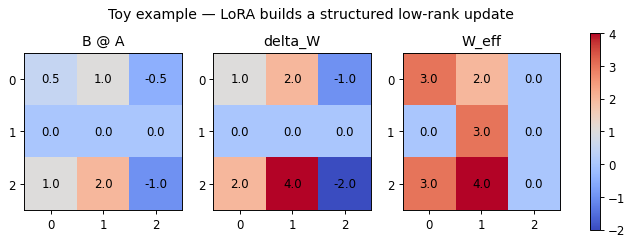

In [19]:
r_lora = 1
alpha_lora = 2.0
scale_lora = alpha_lora / r_lora
A_lora = np.array([[0.5, 1.0, -0.5]])      # 1 x 3 down-projection
B_lora = np.array([[1.0], [0.0], [2.0]])   # 3 x 1 up-projection

BA_lora = B_lora @ A_lora
delta_W_lora = scale_lora * BA_lora
W_effective_lora = W_lora + delta_W_lora
y_bigmatrix = W_effective_lora @ x_lora

log("rank r", r_lora)
log("alpha", alpha_lora)
log("scale = alpha/r", scale_lora)
log("A down-projection shape", A_lora.shape)
log("A", A_lora.tolist())
log("B up-projection shape", B_lora.shape)
log("B", B_lora.tolist())
log("B @ A rank-1 outer product", BA_lora.tolist())
log("delta_W = scale * B @ A", delta_W_lora.astype(int).tolist())
log("W_eff = W + delta_W", W_effective_lora.astype(int).tolist())
log("y' = W_eff @ x", y_bigmatrix.astype(int).tolist())
assert np.allclose(BA_lora, [[0.5, 1.0, -0.5], [0.0, 0.0, 0.0], [1.0, 2.0, -1.0]])
assert np.allclose(delta_W_lora, [[1.0, 2.0, -1.0], [0.0, 0.0, 0.0], [2.0, 4.0, -2.0]])
assert np.allclose(W_effective_lora, [[3.0, 2.0, 0.0], [0.0, 3.0, 0.0], [3.0, 4.0, 0.0]])
assert np.allclose(y_bigmatrix, [7.0, 6.0, 11.0])
assert np.linalg.matrix_rank(BA_lora) == 1

fig, axes = plt.subplots(1, 3, figsize=(9, 3))
for ax, mat, title in zip(axes, [BA_lora, delta_W_lora, W_effective_lora], ["B @ A", "delta_W", "W_eff"]):
    im = ax.imshow(mat, cmap="coolwarm", vmin=-2, vmax=4)
    ax.set_title(title)
    ax.set_xticks(range(3)); ax.set_yticks(range(3))
    for i in range(mat.shape[0]):
        for j in range(mat.shape[1]):
            ax.text(j, i, f"{mat[i,j]:.1f}", ha="center", va="center")
fig.suptitle("Toy example — LoRA builds a structured low-rank update")
plt.colorbar(im, ax=axes.ravel().tolist(), fraction=0.046)
plt.show()

## Step 6d Toy example · Efficient path without building the big matrix

At training or serving time, LoRA can compute the same output as:

`y' = W @ x + scale * B @ (A @ x)`

Read it left to right: squeeze the input down to `r` dimensions, expand it back, then add the frozen layer output. The extra cost is roughly proportional to the small rank `r`.

In [21]:
Ax_lora = A_lora @ x_lora
ax_scalar = float(Ax_lora[0])
adapter_delta_efficient = scale_lora * (B_lora @ Ax_lora)
y_efficient = y_base + adapter_delta_efficient

log("frozen path W @ x", y_base.astype(int).tolist())
log("A @ x", Ax_lora.tolist())
log("Ax as scalar", ax_scalar)
log("scale * B @ (A @ x)", adapter_delta_efficient.astype(int).tolist())
log("efficient y'", y_efficient.astype(int).tolist())
log("big-matrix y'", y_bigmatrix.astype(int).tolist())
assert np.allclose(Ax_lora, [2.0])
assert np.allclose(adapter_delta_efficient, [4.0, 0.0, 8.0])
assert np.allclose(y_efficient, y_bigmatrix)

[frozen path W @ x] [3, 6, 3]
[A @ x] [2.0]
[Ax as scalar] 2.0
[scale * B @ (A @ x)] [4, 0, 8]
[efficient y'] [7, 6, 11]
[big-matrix y'] [7, 6, 11]


## Step 6e Toy example · Parameter count savings

For a `d × k` layer, full fine-tuning a free update costs `d*k` parameters. LoRA with rank `r` costs `r*(d+k)` parameters because it stores `A` and `B` instead of a full `delta_W`.

[toy full delta_W params] 9
[toy LoRA(r=1) params = A + B] 6
[formula full] d*k
[formula LoRA] r*(d+k)
[d=k=1000 full params] 1,000,000
[d=k=1000, r=4] 8,000 params = 0.8%
[d=k=1000, r=8] 16,000 params = 1.6%
[d=k=1000, r=16] 32,000 params = 3.2%


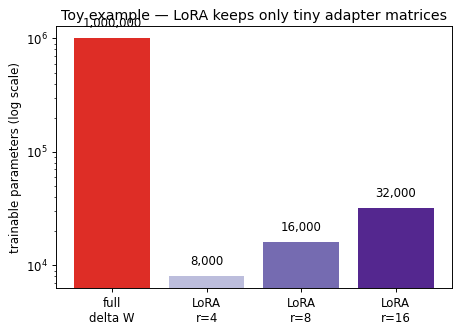

In [23]:
full_delta_toy = W_lora.size
lora_params_toy = A_lora.size + B_lora.size
log("toy full delta_W params", full_delta_toy)
log("toy LoRA(r=1) params = A + B", lora_params_toy)
assert full_delta_toy == 9
assert lora_params_toy == 6

d = 1000
k = 1000
full_params = d * k
ranks = [4, 8, 16]
lora_params_by_rank = [r * (d + k) for r in ranks]
percent_by_rank = [100 * p / full_params for p in lora_params_by_rank]
log("formula full", "d*k")
log("formula LoRA", "r*(d+k)")
log("d=k=1000 full params", f"{full_params:,}")
for r, params, pct in zip(ranks, lora_params_by_rank, percent_by_rank):
    log(f"d=k=1000, r={r}", f"{params:,} params = {pct:.1f}%")
assert lora_params_by_rank == [8000, 16000, 32000]
assert np.allclose(percent_by_rank, [0.8, 1.6, 3.2])

labels = ["full\ndelta W"] + [f"LoRA\nr={r}" for r in ranks]
values = [full_params] + lora_params_by_rank
plt.bar(labels, values, color=["#de2d26", "#bcbddc", "#756bb1", "#54278f"])
plt.yscale("log")
plt.ylabel("trainable parameters (log scale)")
plt.title("Toy example — LoRA keeps only tiny adapter matrices")
for i, v in enumerate(values):
    plt.text(i, v * 1.25, f"{v:,}", ha="center")
plt.show()

## Step 6f Toy example · Initialization starts as a no-op

A common LoRA trick is to initialize `B` to zeros. Then `B @ A = 0`, so the adapter initially changes nothing: `W_eff == W` and `y' == y`. This helps resist catastrophic forgetting at the start of training.

In [25]:
B_init = np.zeros_like(B_lora)
A_init = A_lora.copy()
delta_W_init = scale_lora * (B_init @ A_init)
W_eff_init = W_lora + delta_W_init
y_init = W_eff_init @ x_lora

log("B initialized to zeros", B_init.astype(int).tolist())
log("delta_W at init", delta_W_init.astype(int).tolist())
log("W_eff_init", W_eff_init.astype(int).tolist())
log("y' at init", y_init.astype(int).tolist())
log("original y", y_base.astype(int).tolist())
assert np.allclose(delta_W_init, np.zeros_like(W_lora))
assert np.allclose(W_eff_init, W_lora)
assert np.allclose(y_init, y_base)

[B initialized to zeros] [[0], [0], [0]]
[delta_W at init] [[0, 0, 0], [0, 0, 0], [0, 0, 0]]
[W_eff_init] [[2, 0, 1], [0, 3, 0], [1, 0, 2]]
[y' at init] [3, 6, 3]
[original y] [3, 6, 3]


## Step 6g Toy example · One training step updates only A and B

Now hand-trace one gradient step. The frozen layer `W` does **not** move. Only `A` and `B` receive gradients.

In [27]:
g = np.array([1.0, 0.0, -1.0])
ax = float((A_lora @ x_lora)[0])
btg = float((B_lora.T @ g)[0])
dB_lora = scale_lora * g.reshape(-1, 1) * ax
dA_lora = scale_lora * btg * x_lora.reshape(1, -1)
lr_lora = 0.1
B_new = B_lora - lr_lora * dB_lora
A_new = A_lora - lr_lora * dA_lora

log("g = dL/dy'", g.astype(int).tolist())
log("A @ x scalar", ax)
log("B.T @ g scalar", btg)
log("dL/dB = scale*g*(Ax)", dB_lora.astype(int).ravel().tolist())
log("dL/dA = scale*(B.T@g)*x", dA_lora.astype(int).ravel().tolist())
log("learning rate", lr_lora)
log("B_new", np.round(B_new.ravel(), 3).tolist())
log("A_new", np.round(A_new.ravel(), 3).tolist())
log("W after adapter step", W_lora.astype(int).tolist())
assert np.allclose(dB_lora.ravel(), [4.0, 0.0, -4.0])
assert np.allclose(dA_lora.ravel(), [-2.0, -4.0, -2.0])
assert np.allclose(B_new.ravel(), [0.6, 0.0, 2.4])
assert np.allclose(A_new.ravel(), [0.7, 1.4, -0.3])
assert np.allclose(W_lora, W_lora_before_training)
assert np.allclose(W_lora, [[2, 0, 1], [0, 3, 0], [1, 0, 2]])

[g = dL/dy'] [1, 0, -1]
[A @ x scalar] 2.0
[B.T @ g scalar] -1.0
[dL/dB = scale*g*(Ax)] [4, 0, -4]
[dL/dA = scale*(B.T@g)*x] [-2, -4, -2]
[learning rate] 0.1
[B_new] [0.6, 0.0, 2.4]
[A_new] [0.7, 1.4, -0.3]
[W after adapter step] [[2, 0, 1], [0, 3, 0], [1, 0, 2]]


## Step 6h Toy example · LoRA wrap-up notes

- **MERGE at inference:** compute `W_eff = W + (alpha/r)BA` once, then the served model has zero added adapter latency.
- **One base, many adapters:** keep one frozen pretrained model and swap tiny task adapters in and out.
- **Typical placement:** LoRA is often placed on attention `Q` and `V` matrices.
- **QLoRA:** keep the frozen base quantized, while training higher-precision adapters.

Good for: cheap task adaptation, many task-specific variants, and smaller training memory.  
Watch out for: rank too small can underfit, rank too large loses savings, `alpha` interacts with learning rate, and LoRA usually nudges behavior rather than adding brand-new knowledge from nowhere.

---
# Part C · Fine-tune as ordinary training

## Step 9 Toy example · A tiny dataset for a logistic-regression head

This is the same idea scaled down: a small classifier head learns from labeled examples. **Logistic regression** here is just a one-layer head for two classes.

[X_tiny shape] (8, 2)
[labels] [0, 0, 0, 0, 1, 1, 1, 1]
[meaning] class 0 points are left/down; class 1 points are right/up


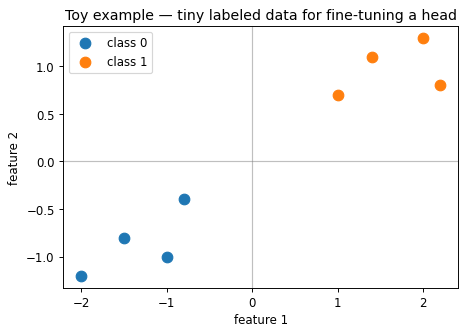

In [30]:
X_tiny = np.array([[-2.0, -1.2], [-1.5, -0.8], [-1.0, -1.0], [-0.8, -0.4],
                   [ 1.0,  0.7], [ 1.4,  1.1], [ 2.0,  1.3], [ 2.2,  0.8]])
y_tiny = np.array([0, 0, 0, 0, 1, 1, 1, 1], dtype=float)
log("X_tiny shape", X_tiny.shape)
log("labels", y_tiny.astype(int).tolist())
log("meaning", "class 0 points are left/down; class 1 points are right/up")

plt.scatter(X_tiny[y_tiny == 0, 0], X_tiny[y_tiny == 0, 1], label="class 0", s=80)
plt.scatter(X_tiny[y_tiny == 1, 0], X_tiny[y_tiny == 1, 1], label="class 1", s=80)
plt.axvline(0, color="gray", lw=1, alpha=0.5)
plt.axhline(0, color="gray", lw=1, alpha=0.5)
plt.title("Toy example — tiny labeled data for fine-tuning a head")
plt.xlabel("feature 1")
plt.ylabel("feature 2")
plt.legend()
plt.show()

## Step 10 Toy example · Train the head with gradient descent

**Gradient descent** means: compute the loss, compute the gradient, take a small step downhill, repeat. We train only the little head parameters `w` and `b`.

[step 0] loss=0.6931, w=[0.0, 0.0], b=0.000
[step 0 gradient] grad_w=[-0.744, -0.456], grad_b=0.000
[step 1] loss=0.4381, w=[0.298, 0.182], b=0.000
[step 1 gradient] grad_w=[-0.505, -0.314], grad_b=0.014
[step 2] loss=0.3160, w=[0.5, 0.308], b=-0.005
[step 2 gradient] grad_w=[-0.37, -0.232], grad_b=0.019
[step 5] loss=0.1753, w=[0.859, 0.535], b=-0.029
[step 5 gradient] grad_w=[-0.202, -0.129], grad_b=0.020
[step 10] loss=0.1044, w=[1.179, 0.74], b=-0.065
[step 10 gradient] grad_w=[-0.116, -0.075], grad_b=0.016
[step 20] loss=0.0602, w=[1.53, 0.967], b=-0.117
[step 20 gradient] grad_w=[-0.064, -0.042], grad_b=0.011
[step 40] loss=0.0339, w=[1.907, 1.213], b=-0.185
[step 40 gradient] grad_w=[-0.035, -0.023], grad_b=0.007
[step 79] loss=0.0190, w=[2.301, 1.469], b=-0.262
[step 79 gradient] grad_w=[-0.019, -0.012], grad_b=0.004
[initial loss] 0.6931
[final loss] 0.019


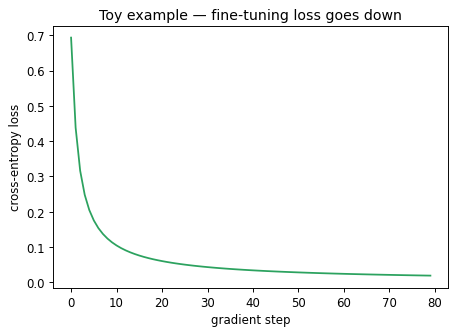

In [32]:
def sigmoid(a):
    return 1 / (1 + np.exp(-a))

w_start = np.zeros(2)
b_start = 0.0
w_lr = w_start.copy()
b_lr = b_start
head_lr = 0.4
loss_history = []
for step in range(80):
    scores = X_tiny @ w_lr + b_lr
    probs = sigmoid(scores)
    loss = -np.mean(y_tiny * np.log(probs + 1e-12) + (1 - y_tiny) * np.log(1 - probs + 1e-12))
    loss_history.append(float(loss))
    grad_scores = (probs - y_tiny) / len(y_tiny)
    grad_w = X_tiny.T @ grad_scores
    grad_b = grad_scores.sum()
    if step in [0, 1, 2, 5, 10, 20, 40, 79]:
        log(f"step {step}", f"loss={loss:.4f}, w={np.round(w_lr,3).tolist()}, b={b_lr:.3f}")
        log(f"step {step} gradient", f"grad_w={np.round(grad_w,3).tolist()}, grad_b={grad_b:.3f}")
    w_lr -= head_lr * grad_w
    b_lr -= head_lr * grad_b

log("initial loss", round(loss_history[0], 4))
log("final loss", round(loss_history[-1], 4))
assert loss_history[-1] < loss_history[0]

plt.plot(loss_history, color="#2ca25f")
plt.xlabel("gradient step")
plt.ylabel("cross-entropy loss")
plt.title("Toy example — fine-tuning loss goes down")
plt.show()

## Step 11 Toy example · The learned decision boundary

A **decision boundary** is the line where the head is exactly unsure: probability 0.5. Points on one side are predicted class 0; the other side is class 1.

[trained w] [2.309, 1.474]
[trained b] -0.264
[probability at origin] 0.434


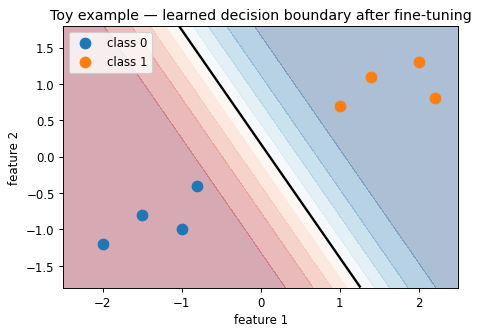

In [34]:
xx, yy = np.meshgrid(np.linspace(-2.5, 2.5, 120), np.linspace(-1.8, 1.8, 120))
grid = np.c_[xx.ravel(), yy.ravel()]
grid_probs = sigmoid(grid @ w_lr + b_lr).reshape(xx.shape)
log("trained w", np.round(w_lr, 3).tolist())
log("trained b", round(float(b_lr), 3))
log("probability at origin", round(float(sigmoid(np.array([0.0, 0.0]) @ w_lr + b_lr)), 3))

plt.contourf(xx, yy, grid_probs, levels=np.linspace(0, 1, 11), cmap="RdBu", alpha=0.35)
plt.contour(xx, yy, grid_probs, levels=[0.5], colors="black", linewidths=2)
plt.scatter(X_tiny[y_tiny == 0, 0], X_tiny[y_tiny == 0, 1], label="class 0", s=80)
plt.scatter(X_tiny[y_tiny == 1, 0], X_tiny[y_tiny == 1, 1], label="class 1", s=80)
plt.title("Toy example — learned decision boundary after fine-tuning")
plt.xlabel("feature 1")
plt.ylabel("feature 2")
plt.legend()
plt.show()

## Step 12 Toy example · Before vs after training predictions

Good for: seeing fine-tuning as "ordinary training on a task."  
Watch out for: with tiny data, a powerful model can memorize; validation data matters.

[start probabilities] [0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5]
[final probabilities] [0.001, 0.007, 0.017, 0.063, 0.956, 0.99, 0.998, 0.998]
[mean P(class 1) on true class 0] 0.022
[mean P(class 1) on true class 1] 0.985


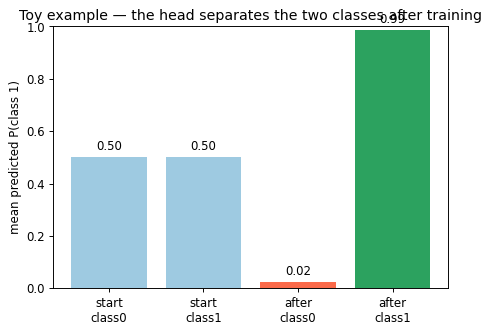

In [36]:
start_probs = sigmoid(X_tiny @ w_start + b_start)
final_probs = sigmoid(X_tiny @ w_lr + b_lr)
log("start probabilities", np.round(start_probs, 3).tolist())
log("final probabilities", np.round(final_probs, 3).tolist())
log("mean P(class 1) on true class 0", f"{final_probs[y_tiny==0].mean():.3f}")
log("mean P(class 1) on true class 1", f"{final_probs[y_tiny==1].mean():.3f}")

means = [start_probs[y_tiny==0].mean(), start_probs[y_tiny==1].mean(),
         final_probs[y_tiny==0].mean(), final_probs[y_tiny==1].mean()]
plt.bar(["start\nclass0", "start\nclass1", "after\nclass0", "after\nclass1"], means,
        color=["#9ecae1", "#9ecae1", "#fb6a4a", "#2ca25f"])
plt.ylim(0, 1)
plt.ylabel("mean predicted P(class 1)")
plt.title("Toy example — the head separates the two classes after training")
for i, v in enumerate(means):
    plt.text(i, v + 0.03, f"{v:.2f}", ha="center")
plt.show()

---
# Part D · Distillation transfers knowledge from teacher to student

## Step 13 Toy example · Hard labels vs soft labels

A **teacher** is the larger or stronger model. A **student** is the smaller model we want to train. **Distillation** trains the student to imitate the teacher.

- **Hard label:** one correct class, like `[1, 0, 0]`.
- **Soft label:** a probability distribution, like `[0.629, 0.231, 0.140]`, which says which wrong answers are more plausible.

[teacher logits] [4.0, 2.0, 1.0]
[hard label for class 0] [1.0, 0.0, 0.0]
[teacher soft label at T=2] [0.629, 0.231, 0.14]
[soft label sum] 1.0


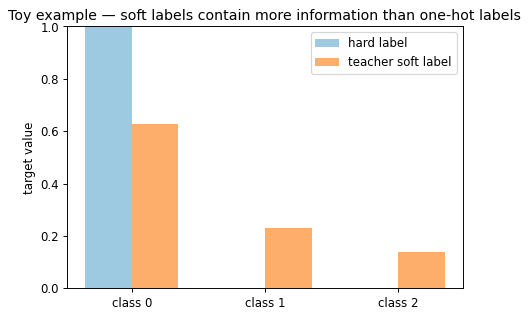

In [38]:
teacher_logits = np.array([4.0, 2.0, 1.0])
hard_label = np.array([1.0, 0.0, 0.0])
teacher_soft_T2 = softmax(teacher_logits, T=2.0)
log("teacher logits", teacher_logits.tolist())
log("hard label for class 0", hard_label.tolist())
log("teacher soft label at T=2", np.round(teacher_soft_T2, 3).tolist())
log("soft label sum", round(float(teacher_soft_T2.sum()), 6))
assert abs(teacher_soft_T2.sum() - 1.0) < 1e-12

xs = np.arange(3)
width = 0.35
plt.bar(xs - width/2, hard_label, width, label="hard label", color="#9ecae1")
plt.bar(xs + width/2, teacher_soft_T2, width, label="teacher soft label", color="#fdae6b")
plt.xticks(xs, ["class 0", "class 1", "class 2"])
plt.ylim(0, 1)
plt.ylabel("target value")
plt.title("Toy example — soft labels contain more information than one-hot labels")
plt.legend()
plt.show()

## Step 14 Toy example · Temperature reveals dark knowledge

**Temperature** smooths the teacher distribution:

$$\mathrm{softmax}(z_i, T) = \frac{e^{z_i/T}}{\sum_j e^{z_j/T}}$$

Higher `T` reveals **dark knowledge**: information about non-winning classes. Here class 1 is more like the answer than class 2.

[T=1 distribution] [0.844, 0.114, 0.042]
[T=2 distribution] [0.629, 0.231, 0.14]
[T=4 distribution] [0.481, 0.292, 0.227]


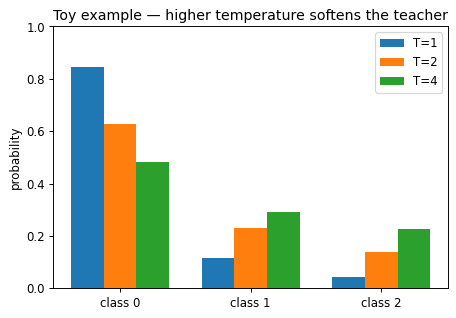

In [40]:
temps = [1.0, 2.0, 4.0]
dist_by_T = np.array([softmax(teacher_logits, T=t) for t in temps])
for t, dist in zip(temps, dist_by_T):
    log(f"T={t:g} distribution", np.round(dist, 3).tolist())
    assert abs(dist.sum() - 1.0) < 1e-12
assert np.allclose(np.round(dist_by_T[0], 3), [0.844, 0.114, 0.042])
assert np.allclose(np.round(dist_by_T[1], 3), [0.629, 0.231, 0.140])
assert np.allclose(np.round(dist_by_T[2], 3), [0.481, 0.292, 0.227])

xs = np.arange(3)
width = 0.25
for i, t in enumerate(temps):
    plt.bar(xs + (i - 1) * width, dist_by_T[i], width, label=f"T={t:g}")
plt.xticks(xs, ["class 0", "class 1", "class 2"])
plt.ylim(0, 1)
plt.ylabel("probability")
plt.title("Toy example — higher temperature softens the teacher")
plt.legend()
plt.show()

## Step 15 Toy example · Dark knowledge says class 1 is closer than class 2

Good for: learning similarities between classes, not just the right answer.  
Watch out for: too high a temperature can make the target too flat.

[T=1: class1 vs class2] 0.114 vs 0.042; ratio=2.72
[T=2: class1 vs class2] 0.231 vs 0.140; ratio=1.65
[T=4: class1 vs class2] 0.292 vs 0.227; ratio=1.28


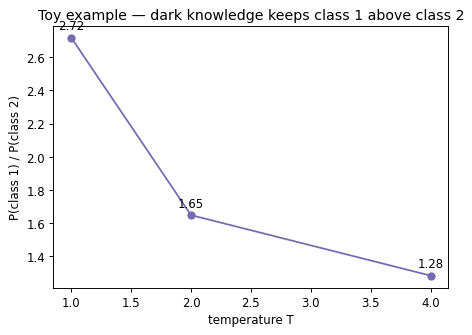

In [42]:
for t, dist in zip(temps, dist_by_T):
    log(f"T={t:g}: class1 vs class2", f"{dist[1]:.3f} vs {dist[2]:.3f}; ratio={dist[1]/dist[2]:.2f}")

ratios = dist_by_T[:, 1] / dist_by_T[:, 2]
plt.plot(temps, ratios, "-o", color="#756bb1")
plt.xlabel("temperature T")
plt.ylabel("P(class 1) / P(class 2)")
plt.title("Toy example — dark knowledge keeps class 1 above class 2")
for t, r in zip(temps, ratios):
    plt.text(t, r + 0.05, f"{r:.2f}", ha="center")
plt.show()

## Step 16 Toy example · Distillation loss combines hard and soft targets

**KL divergence** measures how much one probability distribution differs from another; 0 means identical. **Cross-entropy (CE)** is the usual hard-label classification loss.

The distillation loss can mix both:

$$L = \alpha\,\mathrm{CE}(y, s_{T=1}) + (1-\alpha)\,T^2\,\mathrm{KL}(q_T\;\|\;s_T)$$

where `q_T` is the teacher at temperature `T`, `s_T` is the student at the same temperature, and `alpha` controls the hard-vs-soft mix.

[teacher soft T=2] [0.629, 0.231, 0.14]
[student soft T=2] [0.419, 0.326, 0.254]
[student hard T=1] [0.506, 0.307, 0.186]
[soft = KL(teacher||student)*T^2] 0.365
[hard = CE(student T=1, true class 0)] 0.68
[total = 0.5*hard + 0.5*soft] 0.523


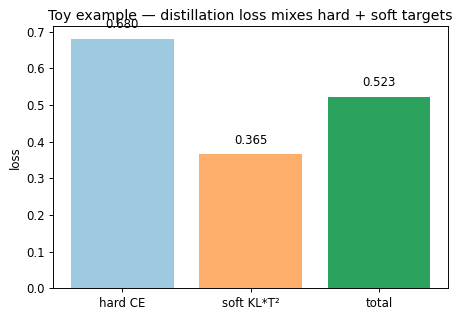

In [44]:
def kl_div(q, p):
    q = np.array(q, dtype=float)
    p = np.array(p, dtype=float)
    return float(np.sum(q * (np.log(q + 1e-12) - np.log(p + 1e-12))))

T = 2.0
alpha = 0.5
true_class = 0
student_logits_initial = np.array([2.5, 2.0, 1.5])
teacher_soft = softmax(teacher_logits, T=T)
student_soft = softmax(student_logits_initial, T=T)
student_hard = softmax(student_logits_initial, T=1.0)
soft_loss = kl_div(teacher_soft, student_soft) * (T ** 2)
hard_loss = -np.log(student_hard[true_class])
total_loss = alpha * hard_loss + (1 - alpha) * soft_loss
log("teacher soft T=2", np.round(teacher_soft, 3).tolist())
log("student soft T=2", np.round(student_soft, 3).tolist())
log("student hard T=1", np.round(student_hard, 3).tolist())
log("soft = KL(teacher||student)*T^2", round(soft_loss, 3))
log("hard = CE(student T=1, true class 0)", round(float(hard_loss), 3))
log("total = 0.5*hard + 0.5*soft", round(float(total_loss), 3))
assert np.allclose(np.round(teacher_soft, 3), [0.629, 0.231, 0.140])
assert np.allclose(np.round(student_soft, 3), [0.419, 0.326, 0.254])
assert abs(soft_loss - 0.365) < 0.01
assert abs(hard_loss - 0.680) < 0.01
assert abs(total_loss - 0.523) < 0.01

plt.bar(["hard CE", "soft KL*T²", "total"], [hard_loss, soft_loss, total_loss],
        color=["#9ecae1", "#fdae6b", "#2ca25f"])
plt.ylabel("loss")
plt.title("Toy example — distillation loss mixes hard + soft targets")
for i, v in enumerate([hard_loss, soft_loss, total_loss]):
    plt.text(i, v + 0.03, f"{v:.3f}", ha="center")
plt.show()

## Step 17 Toy example · Train the student logits

Now we update the student's logits directly, just to make the math visible. Real models update millions or billions of weights, but the loss signal is the same.

[step 0] total=0.5227, KL=0.0913, logits=[2.5, 2.0, 1.5]
[step 1] total=0.4920, KL=0.0843, logits=[2.546, 1.975, 1.479]
[step 2] total=0.4636, KL=0.0778, logits=[2.59, 1.951, 1.459]
[step 5] total=0.3902, KL=0.0613, logits=[2.712, 1.886, 1.403]
[step 10] total=0.2993, KL=0.0411, logits=[2.887, 1.794, 1.319]
[step 20] total=0.1922, KL=0.0186, logits=[3.155, 1.659, 1.186]
[step 40] total=0.1089, KL=0.0043, logits=[3.485, 1.507, 1.007]
[step 60] total=0.0833, KL=0.0024, logits=[3.667, 1.437, 0.895]
[initial KL] 0.0913
[final KL] 0.0024


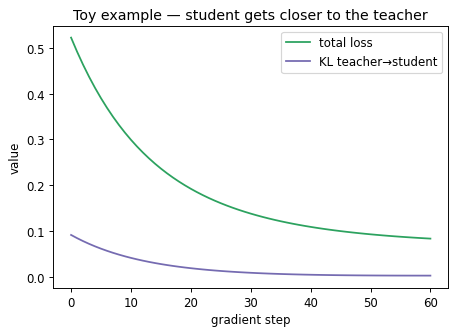

In [46]:
z_student = student_logits_initial.copy()
one_hot = np.eye(3)[true_class]
student_lr = 0.1
total_history, kl_history = [], []
for step in range(61):
    s_hard = softmax(z_student, T=1.0)
    s_soft = softmax(z_student, T=T)
    kl_now = kl_div(teacher_soft, s_soft)
    soft_now = kl_now * (T ** 2)
    hard_now = -np.log(s_hard[true_class])
    total_now = alpha * hard_now + (1 - alpha) * soft_now
    total_history.append(float(total_now))
    kl_history.append(float(kl_now))
    if step in [0, 1, 2, 5, 10, 20, 40, 60]:
        log(f"step {step}", f"total={total_now:.4f}, KL={kl_now:.4f}, logits={np.round(z_student,3).tolist()}")
    if step < 60:
        grad_hard = s_hard - one_hot
        grad_soft = T * (s_soft - teacher_soft)
        grad = alpha * grad_hard + (1 - alpha) * grad_soft
        z_student -= student_lr * grad

student_logits_trained = z_student.copy()
log("initial KL", round(kl_history[0], 4))
log("final KL", round(kl_history[-1], 4))
assert kl_history[-1] < kl_history[0]

plt.plot(total_history, label="total loss", color="#2ca25f")
plt.plot(kl_history, label="KL teacher→student", color="#756bb1")
plt.xlabel("gradient step")
plt.ylabel("value")
plt.title("Toy example — student gets closer to the teacher")
plt.legend()
plt.show()

## Step 18 Toy example · Before vs after distillation distributions

Good for: making a smaller/faster model imitate a bigger one.  
Watch out for: if the teacher is wrong or biased, the student can copy those mistakes.

[teacher soft] [0.629, 0.231, 0.14]
[student initial soft] [0.419, 0.326, 0.254]
[student final soft] [0.634, 0.208, 0.158]
[initial KL -> final KL] 0.0913 -> 0.0024


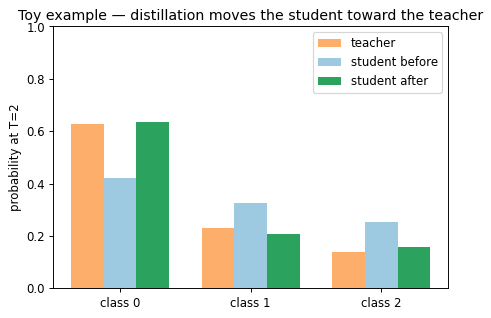

In [48]:
student_soft_initial = softmax(student_logits_initial, T=T)
student_soft_final = softmax(student_logits_trained, T=T)
log("teacher soft", np.round(teacher_soft, 3).tolist())
log("student initial soft", np.round(student_soft_initial, 3).tolist())
log("student final soft", np.round(student_soft_final, 3).tolist())
log("initial KL -> final KL", f"{kl_div(teacher_soft, student_soft_initial):.4f} -> {kl_div(teacher_soft, student_soft_final):.4f}")

xs = np.arange(3)
width = 0.25
plt.bar(xs - width, teacher_soft, width, label="teacher", color="#fdae6b")
plt.bar(xs, student_soft_initial, width, label="student before", color="#9ecae1")
plt.bar(xs + width, student_soft_final, width, label="student after", color="#2ca25f")
plt.xticks(xs, ["class 0", "class 1", "class 2"])
plt.ylim(0, 1)
plt.ylabel("probability at T=2")
plt.title("Toy example — distillation moves the student toward the teacher")
plt.legend()
plt.show()

---
# Part E · Choosing the move

## Step 19 Toy example · Fine-tune vs distill decision table

| Situation | Choose |
|---|---|
| Need best quality on one task | Fine-tune |
| Need small/fast production model | Distill |
| Little labeled data but strong teacher | Distill with pseudo-labels |
| Need both quality and speed | Fine-tune the teacher, then distill to a student |

Good for: matching the method to the bottleneck.  
Watch out for: these compose — you do not have to choose only one forever.

[quality one task] fine-tune
[small/fast prod] distill
[little labels strong teacher] distill
[quality + speed] fine-tune then distill


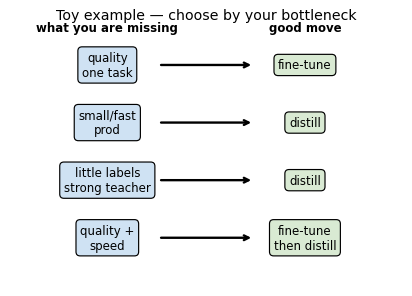

In [50]:
decisions = [
    ("quality\none task", "fine-tune"),
    ("small/fast\nprod", "distill"),
    ("little labels\nstrong teacher", "distill"),
    ("quality +\nspeed", "fine-tune\nthen distill"),
]
for problem, choice in decisions:
    log(problem.replace("\n", " "), choice.replace("\n", " "))

fig, ax = plt.subplots()
ax.axis("off")
for i, (problem, choice) in enumerate(decisions):
    y = 0.85 - i * 0.22
    ax.text(0.25, y, problem, ha="center", va="center", bbox=dict(boxstyle="round,pad=0.35", facecolor="#cfe2f3"))
    ax.text(0.75, y, choice, ha="center", va="center", bbox=dict(boxstyle="round,pad=0.35", facecolor="#d9ead3"))
    ax.annotate("", xy=(0.62, y), xytext=(0.38, y), arrowprops=dict(arrowstyle="->", lw=2))
ax.text(0.25, 0.98, "what you are missing", ha="center", weight="bold")
ax.text(0.75, 0.98, "good move", ha="center", weight="bold")
ax.set_title("Toy example — choose by your bottleneck")
plt.show()

## Step 20 Toy example · Classify vs generate uses the same machinery

For **classify**, the model uses a classification head and CE over class labels. For **generate**, a language-model (**LM**) head predicts the next token many times; **instruction tuning** is fine-tuning on prompt→answer sequences, and **sequence distillation** trains a student on teacher-generated sequences.

[classify] classification head -> target: one label -> loss: CE over classes
[generate] LM head -> target: sequence of tokens -> loss: CE over next tokens


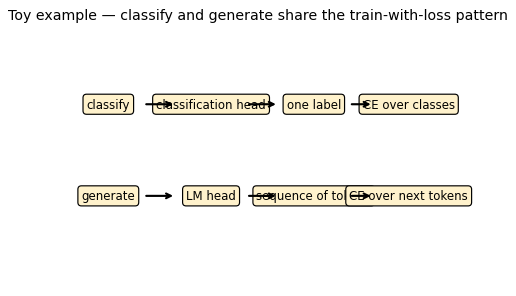

In [52]:
rows = [
    ("classify", "classification head", "one label", "CE over classes"),
    ("generate", "LM head", "sequence of tokens", "CE over next tokens"),
]
for row in rows:
    log(row[0], f"{row[1]} -> target: {row[2]} -> loss: {row[3]}")

fig, ax = plt.subplots()
ax.axis("off")
for i, (task, head, target, loss) in enumerate(rows):
    y = 0.70 - i * 0.35
    xs = [0.12, 0.38, 0.64, 0.88]
    texts = [task, head, target, loss]
    for x, text in zip(xs, texts):
        ax.text(x, y, text, ha="center", va="center",
                bbox=dict(boxstyle="round,pad=0.3", facecolor="#fff2cc", edgecolor="black"))
    for x0, x1 in zip(xs[:-1], xs[1:]):
        ax.annotate("", xy=(x1 - 0.09, y), xytext=(x0 + 0.09, y), arrowprops=dict(arrowstyle="->", lw=1.8))
ax.set_title("Toy example — classify and generate share the train-with-loss pattern")
plt.show()

## Step 21 Toy example · The whole module as one chain

The practical chain is:

**pretrained → fine-tune (adapt) → teacher → distill (shrink) → student → serve**

[chain step] pretrained -> fine-tune (adapt)
[chain step] fine-tune (adapt) -> teacher
[chain step] teacher -> distill (shrink)
[chain step] distill (shrink) -> student
[chain step] student -> serve


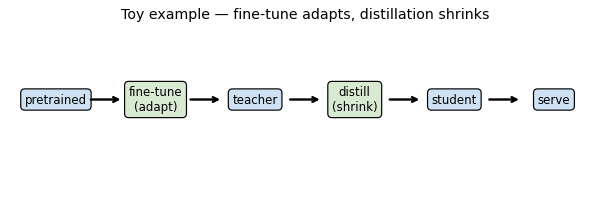

In [54]:
chain = ["pretrained", "fine-tune\n(adapt)", "teacher", "distill\n(shrink)", "student", "serve"]
for left, right in zip(chain[:-1], chain[1:]):
    log("chain step", f"{left.replace(chr(10), ' ')} -> {right.replace(chr(10), ' ')}")

fig, ax = plt.subplots(figsize=(9, 2.5))
ax.axis("off")
xs = np.linspace(0.08, 0.92, len(chain))
for x, text in zip(xs, chain):
    color = "#cfe2f3" if "fine" not in text and "distill" not in text else "#d9ead3"
    ax.text(x, 0.55, text, ha="center", va="center", bbox=dict(boxstyle="round,pad=0.35", facecolor=color, edgecolor="black"))
for x0, x1 in zip(xs[:-1], xs[1:]):
    ax.annotate("", xy=(x1 - 0.055, 0.55), xytext=(x0 + 0.055, 0.55), arrowprops=dict(arrowstyle="->", lw=2))
ax.set_title("Toy example — fine-tune adapts, distillation shrinks")
plt.show()

## Recap — the M20 toolkit

- **Fine-tune adapts.** It uses gradients from your task to update some weights: full model, head only, or LoRA adapters.
- **Distill shrinks.** A teacher gives soft labels; the student learns both the hard answer and the teacher's probability shape.
- They compose: **fine-tune the teacher, then distill to a student**.
- Choose by what you are missing: task quality → fine-tune; production speed/size → distill; little labeled data but a strong teacher → distill with pseudo-labels.
- Classification and generation use the same training idea: a head, targets, probabilities, and a loss.